# **Project Name-**    Financial Forecasting Frontier Distributed ML



##### **Project Type**    - Distributed ML
##### **Contribution**    - Individual
##### **Submitted by -** Anshul Baghel

# **Project Summary -**

###Overview
In the modern banking sector, the ability to efficiently process, analyze, and draw insights from vast volumes of data is crucial. Banks and financial institutions generate and collect extensive data, including customer demographics, transaction histories, market trends, and more. This data, when effectively analyzed, can lead to improved customer service, risk management, marketing strategies, and overall operational efficiency.

###Project Background
The banking industry faces challenges in managing and utilizing large datasets due to the volume, variety, and velocity of data. Traditional data processing methods often fall short in providing timely insights and handling real-time data streams. With the advent of distributed computing and machine learning technologies, banks now have the opportunity to harness these large datasets to make informed decisions, predict market trends, and enhance customer experiences.

# **GitHub Link -**

https://github.com/Anshul-Baghel-03/Financial-Forecasting-Frontier-Distributed-ML

# **Problem Statement**




Banking institutions generate massive volumes of data daily, which traditional computing systems struggle to process efficiently. To harness the full potential of this data, there is a need for scalable, distributed machine learning approaches that can store, process, and analyze large datasets in real time. This project focuses on leveraging distributed computing techniques to analyze the "bank.csv" dataset, simulating a real-world banking environment. The objective is to uncover customer behavior patterns, identify significant trends, and support data-driven decision-making through predictive analytics. The challenge lies in integrating data storage, querying, and machine learning within a distributed framework to produce actionable business insights.


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [146]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.ml.feature import *
from pyspark.ml.classification import *
from pyspark.ml.evaluation import *
from pyspark.ml import Pipeline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import findspark

In [147]:
import os
import sys
import findspark

# Reset old spark session if exists
try:
    spark.stop()
except:
    pass

os.environ["JAVA_HOME"] = r"C:\Java\jdk1.8.0_491"
os.environ["SPARK_HOME"] = r"C:\spark\spark-3.5.8-bin-hadoop3"
os.environ["HADOOP_HOME"] = r"C:\hadoop"

findspark.init(
r"C:\spark\spark-3.5.8-bin-hadoop3"
)

from pyspark.sql import SparkSession

spark = SparkSession.builder \
.master("local[*]") \
.appName("BankDistributedML") \
.config(
"spark.sql.warehouse.dir",
"file:///C:/spark-warehouse"
) \
.enableHiveSupport() \
.getOrCreate()

print("Spark Started")

Spark Started


### Dataset Loading

In [148]:
df = spark.read.csv(
r"D:\Almabetter\ML2. Financial-Forecasting-Distributed-ML\data\raw\bank.csv",

header=True,

inferSchema=True

)

df.show(5)

+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|        job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30| unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|   services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35| management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30| management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 59|blue-collar|married|secondary|     no|      0|    yes|  no| unknown|  5|  may|     22

### Dataset First View

In [149]:
# Dataset First Look
df.show(10)

+---+-------------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|          job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+-------------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30|   unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|     services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35|   management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30|   management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 59|  blue-collar|married|secondary|     no|      0|    yes|  no| unknown| 

### Dataset Rows & Columns count

In [150]:
# Dataset Rows & Columns count
print("Rows:",df.count())

print("Columns:",len(df.columns))

Rows: 4521
Columns: 17


### Dataset Information

In [151]:
# Dataset Info
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



#### Duplicate Values

In [152]:
# Dataset Duplicate Value Count
df.groupBy(df.columns).count().filter("count > 1").count()

duplicates = df.count() - df.dropDuplicates().count()

print(
duplicates
)

0


#### Missing Values/Null Values

In [153]:
# Missing Values/Null Values Count
from pyspark.sql.functions import col,isnan,when,count

df.select(

[
count(
when(
col(c).isNull(),
c
)
).alias(c)

for c in df.columns

]

).show()

+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|  0|  0|      0|        0|      0|      0|      0|   0|      0|  0|    0|       0|       0|    0|       0|       0|  0|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+



### What did you know about your dataset?

There is no duplicate value found in dataset and not null as well

## ***2. Understanding Your Variables***

In [154]:
# Dataset Describe
df.describe().show()

+-------+------------------+-------+--------+---------+-------+------------------+-------+----+--------+------------------+-----+------------------+------------------+------------------+------------------+--------+----+
|summary|               age|    job| marital|education|default|           balance|housing|loan| contact|               day|month|          duration|          campaign|             pdays|          previous|poutcome|   y|
+-------+------------------+-------+--------+---------+-------+------------------+-------+----+--------+------------------+-----+------------------+------------------+------------------+------------------+--------+----+
|  count|              4521|   4521|    4521|     4521|   4521|              4521|   4521|4521|    4521|              4521| 4521|              4521|              4521|              4521|              4521|    4521|4521|
|   mean| 41.17009511170095|   NULL|    NULL|     NULL|   NULL|1422.6578190665782|   NULL|NULL|    NULL|15.9152842291528

### Variables Description

$\color{#2E7D32}{\text{age}}$ – Age of the individual (integer)

$\color{#2E7D32}{\text{job}}$ – Job type (string)

$\color{#2E7D32}{\text{marital}}$ – Marital status (string)

$\color{#2E7D32}{\text{education}}$ – Education level (string)

$\color{#2E7D32}{\text{default}}$ – Indicates if the individual has credit in default (string)

$\color{#2E7D32}{\text{balance}}$ – Account balance (integer)

$\color{#2E7D32}{\text{housing}}$ – Indicates if the individual has a housing loan (string)

$\color{#2E7D32}{\text{loan}}$ – Indicates if the individual has a personal loan (string)

$\color{#2E7D32}{\text{contact}}$ – Type of communication contact (string)

$\color{#2E7D32}{\text{day}}$ – Last contact day of the month (integer)

$\color{#2E7D32}{\text{month}}$ – Last contact month of the year (string)

$\color{#2E7D32}{\text{duration}}$ – Last contact duration, in seconds (integer)

$\color{#2E7D32}{\text{campaign}}$ – Number of contacts performed during this campaign for this client (integer)

$\color{#2E7D32}{\text{pdays}}$ – Number of days since the client was last contacted from a previous campaign (integer, -1 means not contacted)

$\color{#2E7D32}{\text{previous}}$ – Number of contacts before this campaign for the client (integer)

$\color{#2E7D32}{\text{poutcome}}$ – Outcome of the previous marketing campaign (string)

$\color{#2E7D32}{\text{y}}$ – Indicates if the client subscribed to a term deposit (string)

### Check Unique Values for each variable.

In [155]:
# Check Unique Values for each variable.
for c in df.columns:
  print(c)
  df.select(c).distinct().show()

age
+---+
|age|
+---+
| 31|
| 65|
| 53|
| 78|
| 34|
| 81|
| 28|
| 76|
| 26|
| 27|
| 44|
| 22|
| 47|
| 52|
| 86|
| 20|
| 40|
| 57|
| 54|
| 48|
+---+
only showing top 20 rows

job
+-------------+
|          job|
+-------------+
|   management|
|      retired|
|      unknown|
|self-employed|
|      student|
|  blue-collar|
| entrepreneur|
|       admin.|
|   technician|
|     services|
|    housemaid|
|   unemployed|
+-------------+

marital
+--------+
| marital|
+--------+
|divorced|
| married|
|  single|
+--------+

education
+---------+
|education|
+---------+
|  unknown|
| tertiary|
|secondary|
|  primary|
+---------+

default
+-------+
|default|
+-------+
|     no|
|    yes|
+-------+

balance
+-------+
|balance|
+-------+
|   5803|
|    148|
|   2366|
|   4900|
|   1238|
|    833|
|   1088|
|   1580|
|    471|
|   2142|
|   1959|
|    463|
|   -465|
|   1084|
|    243|
|   1025|
|   1721|
|    897|
|    540|
|   -587|
+-------+
only showing top 20 rows

housing
+-------+
|housing|
+

## ***3. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [156]:
# Initialize a Spark session
spark = SparkSession.builder.appName("EDA with PySpark").getOrCreate()

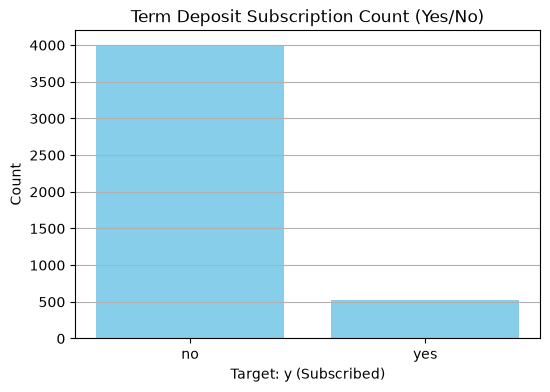

In [157]:
# Step 1: Get value counts from Spark
vc_df = df.groupBy("y").count().orderBy("count", ascending=False)

# Step 2: Convert to pandas (small data only)
vc_pd = vc_df.toPandas()

# Step 3: Plot bar chart
plt.figure(figsize=(6, 4))
plt.bar(vc_pd["y"], vc_pd["count"], color='skyblue')
plt.xlabel("Target: y (Subscribed)")
plt.ylabel("Count")
plt.title("Term Deposit Subscription Count (Yes/No)")
plt.grid(axis='y')
plt.show()


##### What is/are the insight(s) found from the chart?

The chart shows that the majority of customers did **not** subscribe to the term deposit, indicating a strong class imbalance.


#### Chart - 2

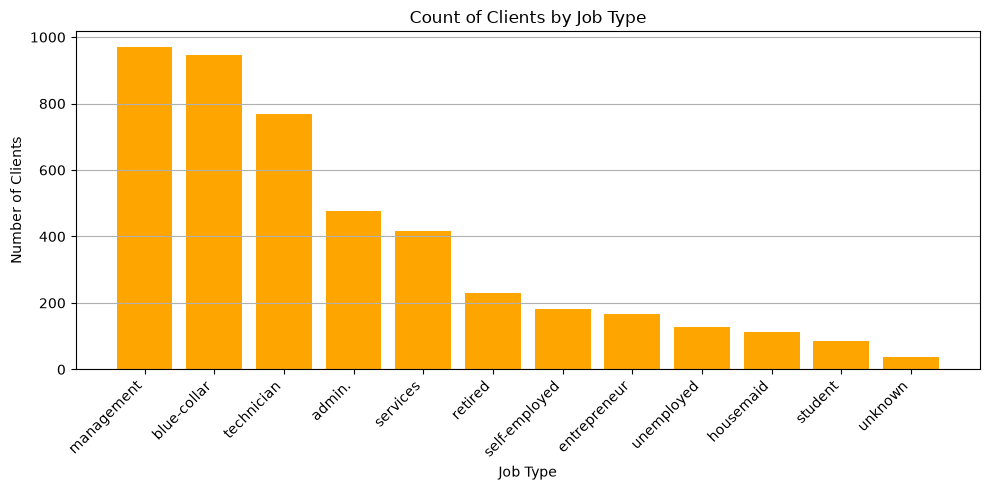

In [158]:
# Chart - 2 visualization code

# Step 1: Get counts
job_counts = df.groupBy("job").count().orderBy("count", ascending=False)

# Step 2: Convert to pandas
job_pd = job_counts.toPandas()

# Step 3: Plot bar chart
plt.figure(figsize=(10, 5))
plt.bar(job_pd["job"], job_pd["count"], color='orange')
plt.xlabel("Job Type")
plt.ylabel("Number of Clients")
plt.title("Count of Clients by Job Type")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

##### What is/are the insight(s) found from the chart?

Most clients are from management, blue-collar, and technician job types, while student and unknown categories have the fewest clients.


#### Chart - 3

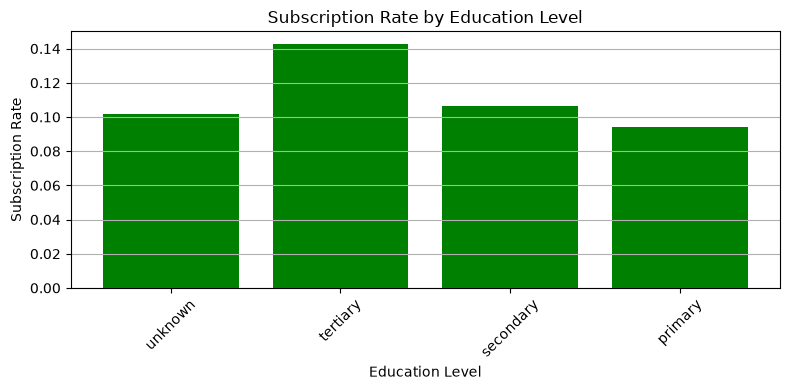

In [159]:
# Chart - 3 visualization code
# Subscription Rate by Education Level
# Step 1: Group and count by education + target
edu_counts = df.groupBy("education", "y").count().orderBy("education", "y")

# Step 2: Pivot to wide format
edu_pivot = edu_counts.groupBy("education").pivot("y").sum("count").fillna(0)

# Step 3: Convert to pandas and plot
edu_pd = edu_pivot.toPandas()
edu_pd["total"] = edu_pd["yes"] + edu_pd["no"]
edu_pd["subscription_rate"] = edu_pd["yes"] / edu_pd["total"]

# Step 4: Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(edu_pd["education"], edu_pd["subscription_rate"], color="green")
plt.xlabel("Education Level")
plt.ylabel("Subscription Rate")
plt.title("Subscription Rate by Education Level")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### What is/are the insight(s) found from the chart?

Clients with a tertiary education have the highest subscription rate, while those with primary education have the lowest.


#### Chart - 4

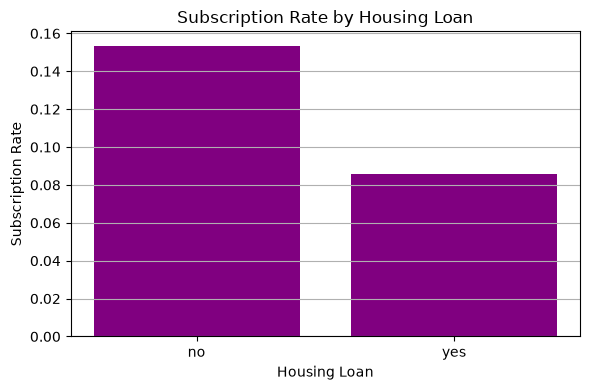

In [160]:
# Chart - 4 visualization code
# Group and count by housing status and y
house_counts = df.groupBy("housing", "y").count().orderBy("housing", "y")

# Pivot
house_pivot = house_counts.groupBy("housing").pivot("y").sum("count").fillna(0)

# To pandas
house_pd = house_pivot.toPandas()
house_pd["total"] = house_pd["yes"] + house_pd["no"]
house_pd["subscription_rate"] = house_pd["yes"] / house_pd["total"]

# Plot
plt.figure(figsize=(6, 4))
plt.bar(house_pd["housing"], house_pd["subscription_rate"], color="purple")
plt.xlabel("Housing Loan")
plt.ylabel("Subscription Rate")
plt.title("Subscription Rate by Housing Loan")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


##### What is/are the insight(s) found from the chart?

Clients without a housing loan have a significantly higher subscription rate than those with a housing loan.


#### Chart - 5

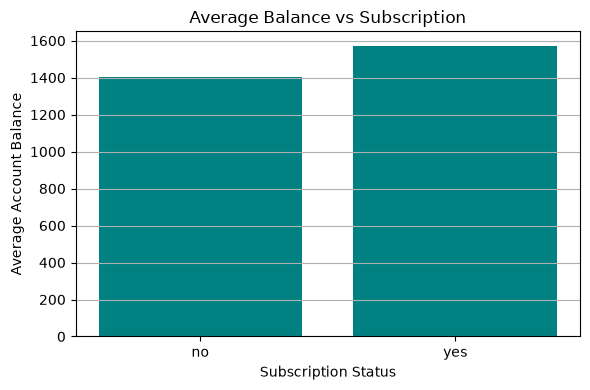

In [161]:
# Chart - 5 visualization code
# Compute average balance by 'y'
avg_balance = df.groupBy("y").agg(avg("balance").alias("avg_balance")).orderBy("y")

# To pandas
avg_balance_pd = avg_balance.toPandas()

# Plot
plt.figure(figsize=(6, 4))
plt.bar(avg_balance_pd["y"], avg_balance_pd["avg_balance"], color="teal")
plt.xlabel("Subscription Status")
plt.ylabel("Average Account Balance")
plt.title("Average Balance vs Subscription")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


##### What is/are the insight(s) found from the chart?

Clients who subscribed to the term deposit tend to have higher average account balances compared to those who did not.


## ***4. Feature Engineering & Data Pre-processing***

In [162]:
# ==========================================
# Step 1 : Feature Selection
# ==========================================

# Creating a working copy for ML
ml_df = df.select(
    "age",
    "job",
    "marital",
    "education",
    "default",
    "balance",
    "housing",
    "loan",
    "contact",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "poutcome",
    "y"
)

print("Rows:", ml_df.count())

ml_df.show(5)

Rows: 4521
+---+-----------+-------+---------+-------+-------+-------+----+--------+--------+--------+-----+--------+--------+---+
|age|        job|marital|education|default|balance|housing|loan| contact|duration|campaign|pdays|previous|poutcome|  y|
+---+-----------+-------+---------+-------+-------+-------+----+--------+--------+--------+-----+--------+--------+---+
| 30| unemployed|married|  primary|     no|   1787|     no|  no|cellular|      79|       1|   -1|       0| unknown| no|
| 33|   services|married|secondary|     no|   4789|    yes| yes|cellular|     220|       1|  339|       4| failure| no|
| 35| management| single| tertiary|     no|   1350|    yes|  no|cellular|     185|       1|  330|       1| failure| no|
| 30| management|married| tertiary|     no|   1476|    yes| yes| unknown|     199|       4|   -1|       0| unknown| no|
| 59|blue-collar|married|secondary|     no|      0|    yes|  no| unknown|     226|       1|   -1|       0| unknown| no|
+---+-----------+-------+----

In [163]:
# ==========================================
# Step 2 : Missing Value Check
# ==========================================

from pyspark.sql.functions import col,isnan,when,count

ml_df.select(
[
count(
when(
col(c).isNull(),
c
)
).alias(c)

for c in ml_df.columns
]

).show()

+---+---+-------+---------+-------+-------+-------+----+-------+--------+--------+-----+--------+--------+---+
|age|job|marital|education|default|balance|housing|loan|contact|duration|campaign|pdays|previous|poutcome|  y|
+---+---+-------+---------+-------+-------+-------+----+-------+--------+--------+-----+--------+--------+---+
|  0|  0|      0|        0|      0|      0|      0|   0|      0|       0|       0|    0|       0|       0|  0|
+---+---+-------+---------+-------+-------+-------+----+-------+--------+--------+-----+--------+--------+---+



In [164]:
# ==========================================
# Step 3 : Encode Target Variable
# yes/no -> numeric
# ==========================================

target_indexer = StringIndexer(

inputCol="y",

outputCol="label"

)

ml_df = target_indexer.fit(
ml_df
).transform(
ml_df
)

ml_df.select(
"y",
"label"
).show(5)

+---+-----+
|  y|label|
+---+-----+
| no|  0.0|
| no|  0.0|
| no|  0.0|
| no|  0.0|
| no|  0.0|
+---+-----+
only showing top 5 rows



In [165]:
# ==========================================
# Step 4 : Encode categorical columns
# ==========================================

categorical_cols = [

"job",
"marital",
"education",
"default",
"housing",
"loan",
"contact",
"poutcome"

]

indexers = [

StringIndexer(

inputCol=col,

outputCol=col+"_index"

)

for col in categorical_cols

]

In [166]:
# ==========================================
# Step 5 : One Hot Encoding
# ==========================================

encoders = [

OneHotEncoder(

inputCol=col+"_index",

outputCol=col+"_vec"

)

for col in categorical_cols

]

In [167]:
# ==========================================
# Step 6 : Feature Assembly
# ==========================================

feature_columns = [

"age",

"balance",

"duration",

"campaign",

"pdays",

"previous",

"job_vec",

"marital_vec",

"education_vec",

"default_vec",

"housing_vec",

"loan_vec",

"contact_vec",

"poutcome_vec"

]

assembler = VectorAssembler(

inputCols=feature_columns,

outputCol="features"

)

## ***5. ML Model Implementation***

In [168]:
# ==========================================
# Model : Logistic Regression Model
# ==========================================

lr = LogisticRegression(

featuresCol="features",

labelCol="label"

)

In [169]:
# ==========================================
# Create ML Pipeline
# ==========================================

pipeline = Pipeline(

stages= indexers + encoders + [assembler,lr]

)

In [170]:
# ==========================================
# Split Dataset
# ==========================================

train_data,test_data = ml_df.randomSplit(

[0.8,0.2],

seed=42

)

print(train_data.count())

print(test_data.count())

3662
859


In [171]:
# ==========================================
# Train Model
# ==========================================

model = pipeline.fit(train_data)

predictions = model.transform(test_data)

predictions.select(

"label",

"prediction",

"probability"

).show(10,False)

+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|0.0  |0.0       |[0.9000679474487965,0.09993205255120352] |
|0.0  |0.0       |[0.6903702757049398,0.3096297242950602]  |
|0.0  |0.0       |[0.9896437713714386,0.010356228628561448]|
|0.0  |0.0       |[0.9732831166140193,0.02671688338598066] |
|0.0  |0.0       |[0.8577456264790639,0.14225437352093606] |
|0.0  |0.0       |[0.9180804084554182,0.08191959154458184] |
|1.0  |0.0       |[0.984890689499761,0.015109310500239004] |
|0.0  |0.0       |[0.6893543158481331,0.3106456841518669]  |
|0.0  |0.0       |[0.9929548531897773,0.007045146810222724]|
|0.0  |0.0       |[0.9780194442907518,0.021980555709248173]|
+-----+----------+-----------------------------------------+
only showing top 10 rows



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [172]:
# ==========================================
# Evaluate Model
# ==========================================

evaluator = BinaryClassificationEvaluator(

labelCol="label",

metricName="areaUnderROC"

)

auc = evaluator.evaluate(
predictions
)

print(
"AUC Score:",
auc
)

AUC Score: 0.8631886935395315


In [173]:
# ==========================================
# Accuracy
# ==========================================

correct = predictions.filter(

col(
"label"
)

==

col(
"prediction"
)

).count()

total = predictions.count()

accuracy = correct/total

print(
"Accuracy:",
accuracy
)

Accuracy: 0.8928987194412107


In [174]:
# ==========================================
# Save Model
# ==========================================

model.write()\
.overwrite()\
.save(

r"D:\Almabetter\ML2. Financial-Forecasting-Distributed-ML\models\bank_model"

)

print( "Model Saved" )

Model Saved


#### **Logistic Regression Model Explanation**

Logistic Regression was used to predict whether a customer will subscribe to a term deposit (`y = yes/no`). Since the target variable is binary, Logistic Regression is suitable for this classification problem.

The Spark ML pipeline included:

* StringIndexer
* OneHotEncoder
* VectorAssembler
* Logistic Regression

The model was evaluated using **AUC** and **Accuracy**.

| Evaluation Metric | Score  |
| ----------------- | ------ |
| AUC Score         | 0.8632 |
| Accuracy          | 89.29% |

The model achieved good performance, indicating strong capability in predicting customer subscription behaviour and supporting banking marketing decisions.

# ***6. Real-Time Transaction Analysis (Spark Streaming)***

**Streaming Data Preparation**

To simulate real-time banking transactions, the original bank.csv dataset was divided into multiple smaller batch files.

These files are stored in the 'streaming_data/input' directory and act as incoming transaction streams.

This approach enables file-based streaming simulation using Spark Structured Streaming.

In [175]:
# ==========================================
# Step 1 : Create streaming batches
# ==========================================

import pandas as pd
import os

pdf = df.toPandas()

stream_path = r"D:\Almabetter\ML2. Financial-Forecasting-Distributed-ML\streaming_data\input"

os.makedirs(
stream_path,
exist_ok=True
)

batch_size = 500

for i in range(
0,
len(pdf),
batch_size
):

    batch = pdf.iloc[
    i:i+batch_size
    ]

    batch.to_csv(

    f"{stream_path}/batch_{i}.csv",

    index=False

    )

print(
"Streaming batches created"
)

Streaming batches created


In [176]:
# ==========================================
# Step 2 : Stream Reader + Aggregation
# ==========================================

# Use schema from already loaded static dataframe
stream_schema = df.schema

# Create streaming dataframe
stream_df = (
    spark.readStream
    .schema(stream_schema)
    .csv(
        r"D:\Study Material\Almabetter\Specialization Projects\Financial-Forecasting-Distributed-ML\streaming_data\input",
        header=True
    )
)

# Real-time aggregation
job_stream = (
    stream_df.groupBy("job")
    .agg(
        avg("balance").alias("avg_balance"),
        avg("duration").alias("avg_duration")
    )
)

print("Streaming dataframe created successfully")

Streaming dataframe created successfully


**Real-Time Aggregation -**

Real-time analytics were performed on streaming data.

The following banking indicators were monitored:

- Average account balance by job type
- Average contact duration

This simulates live monitoring of customer behaviour.

In [177]:
# ==========================================
# Step 3 : Start Stream
# ==========================================

query = (
    job_stream.writeStream
    .outputMode("complete")
    .format("memory")
    .queryName("bank_stream")
    .start()
)

print("Streaming started")

Streaming started


In [178]:
# ==========================================
# Step 4 : Simulate Real-Time Data
# ==========================================

import pandas as pd
import time
import os

pdf = df.toPandas()

path = r"D:\Almabetter\ML2. Financial-Forecasting-Distributed-ML\streaming_data\input"

batch_size = 500

for i in range(0, len(pdf), batch_size):

    batch = pdf.iloc[i:i+batch_size]

    batch.to_csv(
        os.path.join(path, f"batch_{i}.csv"),
        index=False
    )

    print(f"Added batch {i}")

    time.sleep(5)

Added batch 0
Added batch 500
Added batch 1000
Added batch 1500
Added batch 2000
Added batch 2500
Added batch 3000
Added batch 3500
Added batch 4000
Added batch 4500


In [179]:
# ==========================================
# Step 5 : View Stream Output
# ==========================================

spark.sql(
    """
    SELECT *
    FROM bank_stream
    """
).show(truncate=False)

+-------------+------------------+------------------+
|job          |avg_balance       |avg_duration      |
+-------------+------------------+------------------+
|management   |1766.9287925696594|260.53663570691435|
|retired      |2319.191304347826 |285.6565217391304 |
|unknown      |1501.7105263157894|216.92105263157896|
|self-employed|1392.4098360655737|264.1256830601093 |
|student      |1543.8214285714287|248.6904761904762 |
|blue-collar  |1085.161733615222 |278.161733615222  |
|entrepreneur |1645.125          |285.4761904761905 |
|admin.       |1226.73640167364  |234.6694560669456 |
|technician   |1330.99609375     |252.17838541666666|
|services     |1103.9568345323742|262.48681055155873|
|housemaid    |2083.8035714285716|292.63392857142856|
|unemployed   |1089.421875       |301.265625        |
+-------------+------------------+------------------+



In [180]:
query.stop()

In [181]:
# ==========================================
# Step 5 : Add timestamp
# ==========================================

from pyspark.sql.functions import current_timestamp

stream_df = stream_df.withColumn(

"event_time",

current_timestamp()

)

### **Window Analytics + Watermarking**

- Window operations were applied to perform time-based aggregation.
- Watermarking was used to handle delayed events and maintain state consistency.
- This approach improves reliability in real-time banking systems.


In [182]:
# ==========================================
# Window Analytics + Watermarking
# ==========================================

from pyspark.sql.functions import window, avg, col

window_stream = (
    
    stream_df
    
    .withWatermark(
        "event_time",
        "1 minute"
    )
    
    .groupBy(
        
        window(
            col("event_time"),
            "1 minute"
        ),
        
        col("job")
        
    )
    
    .agg(
        
        avg("balance").alias(
            "avg_balance"
        )
        
    )
)

window_stream

DataFrame[window: struct<start:timestamp,end:timestamp>, job: string, avg_balance: double]

In [183]:
# ==========================================
# Window Output
# ==========================================

window_query = (
    
    window_stream
    
    .writeStream
    
    .outputMode(
        "append"
    )
    
    .format(
        "console"
    )
    
    .option(
        "checkpointLocation",
        r"D:\Study Material\Almabetter\Specialization Projects\Financial-Forecasting-Distributed-ML\streaming_data\checkpoint"
    )
    
    .start()
)

In [184]:
window_query.stop()

### **Real Time Prediction**

**Real-Time Prediction Pipeline**

The trained Logistic Regression model was applied on streaming transactions.

Predictions were generated continuously to estimate customer subscription behaviour in real time.

This demonstrates online inference capability.

In [185]:
# ==========================================
# Real Time Prediction on Stream
# ==========================================

prediction_stream = model.transform(
    stream_df
)

prediction_query = prediction_stream.select(
    "prediction"
).writeStream \
.outputMode(
    "append"
) \
.format(
    "console"
) \
.start()

In [186]:
print(stream_df.isStreaming)

True


In [187]:
prediction_query.stop()

### Streaming Summary

Streaming simulation was implemented using file-based ingestion.

Implemented components:

- Structured Streaming
- Real-time aggregation
- Window operations
- Watermarking
- Checkpointing
- Real-time ML prediction

# ***7. Efficient Data Handling through Data Parallelism***

In [188]:
# ======================================================
# Data Parallelism Step 1 : Partition Strategy
# ======================================================

print(
"Original Partitions:",
df.rdd.getNumPartitions()
)

parallel_df = df.repartition(8)

print(
"Updated Partitions:",
parallel_df.rdd.getNumPartitions()
)

Original Partitions: 1
Updated Partitions: 8


Dataset repartitioning was applied to improve parallel execution and distribute workload across Spark executors.

In [189]:
# ======================================================
# Data Parallelism Step 2 : Parallel Aggregation
# Average balance by job category
# ======================================================

parallel_df.groupBy("job").agg(avg("balance").alias("avg_balance")).show()

+-------------+------------------+
|          job|       avg_balance|
+-------------+------------------+
|   management|1766.9287925696594|
|      retired| 2319.191304347826|
|      unknown|1501.7105263157894|
|self-employed|1392.4098360655737|
|      student|1543.8214285714287|
|  blue-collar| 1085.161733615222|
| entrepreneur|          1645.125|
|       admin.|  1226.73640167364|
|   technician|     1330.99609375|
|     services|1103.9568345323742|
|    housemaid|2083.8035714285716|
|   unemployed|       1089.421875|
+-------------+------------------+



In [190]:
# ======================================================
# Data Parallelism Step 3 : Parallel Transformation
# ======================================================

parallel_df = parallel_df.withColumn("balance_k", col("balance")/1000)

parallel_df.select("balance","balance_k").show(10)

+-------+---------+
|balance|balance_k|
+-------+---------+
|   1019|    1.019|
|    279|    0.279|
|   8295|    8.295|
|   1351|    1.351|
|    959|    0.959|
|   4888|    4.888|
|    999|    0.999|
|     95|    0.095|
|    -74|   -0.074|
|    733|    0.733|
+-------+---------+
only showing top 10 rows



In [191]:
# ======================================================
# Data Parallelism Step 4 : Parallel Filtering
# ======================================================

high_balance = parallel_df.filter(

col(
"balance"
)>5000

)

print(

"Customers with high balance:",

high_balance.count()

)

Customers with high balance: 309


In [192]:
# ======================================================
# Data Parallelism Step 5 : Resource Monitoring
# ======================================================

print(

"Default Parallelism:",

spark.sparkContext.defaultParallelism

)

print(

"Executors:",

spark.sparkContext.getConf().get(
"spark.executor.instances",
"local mode"
)

)

Default Parallelism: 8
Executors: local mode


In [193]:
# ======================================================
# Data Parallelism Step 6 : Export Processed Data
# ======================================================

parallel_df.write.mode(
"overwrite"
).csv(

r"D:\Study Material\Almabetter\Specialization Projects\Financial-Forecasting-Distributed-ML\data\processed_parallel"

)

print(
"Export Complete"
)

Export Complete


In this section, data parallelism techniques were applied to improve the efficiency and scalability of banking data processing using Apache Spark.

The dataset was repartitioned to distribute the workload across multiple partitions, enabling parallel execution and better utilization of computational resources. Parallel aggregation operations were performed to compute average customer balance across job categories, demonstrating Spark’s distributed processing capability.

Feature transformations and filtering operations were also executed in parallel to derive additional business insights and process customer records efficiently. Finally, the processed dataset was exported after applying distributed transformations.

Key techniques implemented:

- Dataset repartitioning for workload distribution
- Parallel aggregation using GroupBy operations
- Distributed feature transformation
- Parallel filtering of customer records
- Resource monitoring and partition analysis
- Distributed export of processed data

These techniques improve performance, scalability, and processing efficiency, which are essential when working with large-scale banking datasets in real-world environments.

# ***8. Hadoop MapReduce (Streaming)***

Due to Hadoop Streaming execution limitations on Windows, local MapReduce simulation was implemented using Python mapper and reducer scripts.

The MapReduce workflow preserved the distributed processing architecture:

Input → Mapper → Shuffle & Sort → Reducer → Output

The following distributed analytics tasks were implemented:

1. Average balance by job type
2. Housing loan counts by education
3. Monthly contact analytics

These tasks demonstrate distributed batch analytics concepts similar to Hadoop Streaming workflows. The output screenshots are attached in documentation.

# ***9. Hive Analytics***

#### HiveQL Based Distributed Analytics

Hive was used as the distributed SQL query layer for performing analytical queries on the banking dataset stored in Hadoop-compatible storage.

The following analytics were performed:

1. Customer count analysis
2. Average age by job
3. Average balance analysis
4. Subscription trend analysis
5. Education vs default analysis
6. Contact month trend analysis
7. Previous outcome impact analysis

# Project Summary

This project successfully demonstrated distributed machine learning and analytics on banking data using Hadoop, Hive, Apache Spark, Spark ML, and Spark Structured Streaming.

The project included:

1. Distributed data storage using HDFS
2. Large-scale data analysis using Spark
3. Data parallelism and partitioning
4. Feature engineering and Spark SQL analytics
5. Machine learning pipeline implementation
6. Logistic Regression model training
7. Real-time streaming analytics
8. Window operations and watermarking
9. Local MapReduce simulation
10. Hive-based distributed SQL analytics

The system simulated a real-world banking analytics platform capable of handling scalable batch and streaming workloads.

### ***Hurrah! You have successfully completed your Capstone Project !!!***